In [9]:
!pip install opencv-python

In [3]:
from google.colab import files
uploaded = files.upload()

Saving normal.jpg to normal.jpg


In [4]:
from google.colab import files
uploaded = files.upload()

Saving tumor.jpg to tumor.jpg


Files in directory: ['.config', 'tumor.jpg', 'normal.jpg', 'sample_data']
Both images loaded successfully


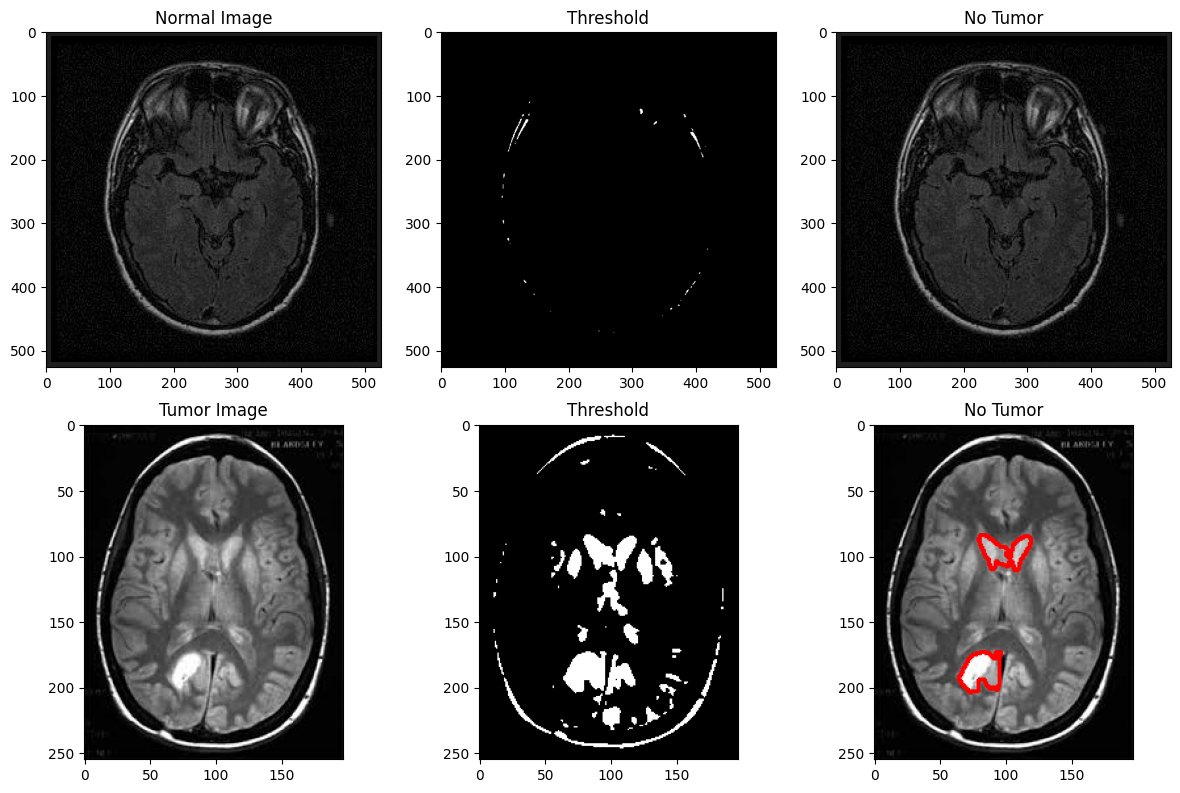

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Files in directory:", os.listdir())

# Use your exact filenames here
img1 = cv2.imread("normal.jpg")   # normal image
img2 = cv2.imread("tumor.jpg")  # tumor image (edit name properly)

def process_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 140, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    output = image.copy()
    large_contours = 0

    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            cv2.drawContours(output, [cnt], -1, (0, 0, 255), 2)
            large_contours += 1

    return thresh, output, large_contours


def classify(count):
    if count > 5:
        return "Tumor Detected"
    else:
        return "No Tumor"


# Safety check
if img1 is None or img2 is None:
    print("Error: One or both images not loaded. Check filenames.")
else:
    print("Both images loaded successfully")

    thresh1, output1, count1 = process_image(img1)
    thresh2, output2, count2 = process_image(img2)

    label1 = classify(count1)
    label2 = classify(count2)

    # Display results
    plt.figure(figsize=(12,8))

    # Row 1 → Normal
    plt.subplot(2,3,1)
    plt.title("Normal Image")
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

    plt.subplot(2,3,2)
    plt.title("Threshold")
    plt.imshow(thresh1, cmap='gray')

    plt.subplot(2,3,3)
    plt.title(label1)
    plt.imshow(cv2.cvtColor(output1, cv2.COLOR_BGR2RGB))

    # Row 2 → Tumor
    plt.subplot(2,3,4)
    plt.title("Tumor Image")
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))

    plt.subplot(2,3,5)
    plt.title("Threshold")
    plt.imshow(thresh2, cmap='gray')

    plt.subplot(2,3,6)
    plt.title(label2)
    plt.imshow(cv2.cvtColor(output2, cv2.COLOR_BGR2RGB))

    plt.tight_layout()
    plt.show()